In [45]:
import torch
import torch.nn as nn


AttributeError: 'Embedding' object has no attribute 'dim'

In [ ]:
weight=weight.unsqueeze(0)
weight=weight.repeat(2,1,1)
weight.shape

torch.Size([2, 5, 10])

In [47]:
data=torch.randn(5)
data

tensor([-0.2962, -0.0596,  0.2440,  1.0034, -0.2155])

In [62]:
a=torch.randperm(10)
a

tensor([3, 6, 0, 8, 9, 4, 5, 2, 7, 1])

In [63]:
import numpy as np
class MINE(nn.Module):
    def __init__(self,hidden_size,config):
        super(MINE,self).__init__()
        self.config=config
        self.layers=nn.Sequential(nn.Linear(config['slide_win']+config['node_dim'],hidden_size),
                                nn.ReLU(),nn.Linear(hidden_size,1))
    def forward(self,x,y):
        batch_size=self.config['batch_size']
        tiled_x=torch.cat([x,x],dim=1)
        idx=torch.randperm(batch_size)
        shuffled_y=y[idx]
        concat_y=torch.cat([y,shuffled_y],dim=1)
        inputs=torch.cat([tiled_x,concat_y],dim=-1)
        logits=self.layers(inputs)

        pred_xy=logits[:batch_size]
        pred_x_y=logits[batch_size:]
        loss_MI=-np.log2(np.exp(1))*(torch.mean(pred_xy))-torch.log(torch.mean(torch.exp(pred_x_y)))
        return loss_MI


In [65]:
config={'slide_win':15,'node_dim':64,'batch_size':5}
model=MINE(128,config)
x=torch.Tensor(5,27,15)
y=torch.Tensor(5,27,64)
loss=model(x,y)



tensor(nan, grad_fn=<SubBackward0>)

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F

x=torch.tensor([[1,2],[-2,3]],dtype=torch.float32)
x


tensor([[ 1.,  2.],
        [-2.,  3.]])

In [19]:
m=nn.ReLU(inplace=True)
x=m(x)
x=F.softmax(x,dim=-1)
x

tensor([[0.2689, 0.7311],
        [0.0474, 0.9526]])

In [35]:
import torch
def diff(X,Y,Z):
    diff=torch.sum(torch.pow(X-Y,2),dim=[1,2])
    norm=torch.sum(torch.pow(Z,2),dim=[1,2])
    diff=diff/torch.clamp(norm,min=1e-4)
    return diff

In [37]:
x=torch.rand(2,4,4)
y=torch.rand(2,4,4)
z=torch.rand(2,4,4)
print(torch.gt(diff(x,y,z),0.1*torch.ones_like(diff(x,y,z))))

print(torch.gt(diff(x,y,z),torch.ones_like(diff(x,y,z))).sum().item())


tensor([True, True])
0


In [8]:
import torch
sensor=torch.Tensor(3,5)
sensor=torch.tensor(sensor,requires_grad=True)
print(sensor)

tensor([[9.5510e-39, 1.0286e-38, 4.2246e-39, 1.0286e-38, 1.0653e-38],
        [1.0194e-38, 8.4490e-39, 1.0469e-38, 9.3674e-39, 9.9184e-39],
        [8.7245e-39, 9.2755e-39, 8.9082e-39, 9.9184e-39, 8.4490e-39]],
       requires_grad=True)


<ipython-input-8-4adda951ee06>:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sensor=torch.tensor(sensor,requires_grad=True)


In [10]:
import numpy as np
a=[1,2,3,43]
np.mean(a)

12.25

In [18]:
import torch
a=torch.Tensor(2,3)
a=a.clone().detach().requires_grad_(True)
a


tensor([[0., 0., 0.],
        [0., 0., 0.]], requires_grad=True)

In [19]:
import torch
a=torch.Tensor(128,27,64)
b=torch.Tensor(128,27,64)
c=torch.cat([a,b],dim=-1)
c.shape

torch.Size([128, 27, 128])

In [14]:
import torch
device=torch.device('cuda')
a=torch.tensor([1,23,4])
a.to(device)
c=a*a
print(a)
a.device

tensor([ 1, 23,  4])


device(type='cpu')

In [13]:
import torch
z=torch.randn(2,3,4)
print(z)
print(torch.mean(z,dim=0))

tensor([[[-0.8187,  0.3461,  0.3709, -0.0548],
         [-0.8815, -1.3995, -0.8895,  0.2604],
         [-0.7095, -0.7730,  0.6199,  0.0816]],

        [[ 0.8136, -0.3483, -0.8430,  0.8883],
         [-0.4892, -0.3933,  1.5108, -0.7452],
         [-0.9621, -0.6601, -1.0017, -0.2436]]])
tensor([[-0.0026, -0.0011, -0.2361,  0.4167],
        [-0.6853, -0.8964,  0.3107, -0.2424],
        [-0.8358, -0.7165, -0.1909, -0.0810]])


In [26]:
import torch
import torch.nn as nn
a=torch.Tensor(2,3,4)
print(a)
a=nn.init.xavier_uniform_(a)
a=nn.Parameter(a,requires_grad=True)
a=a[0]
print(a)


tensor([[[2.5226e-18, 1.0372e-08, 1.0470e-11, 7.7195e-10],
         [2.6227e-09, 4.0061e-11, 1.0740e-05, 2.9570e-18],
         [6.7333e+22, 1.7591e+22, 1.7184e+25, 4.3222e+27]],

        [[6.1972e-04, 7.2443e+22, 1.7728e+28, 7.0367e+22],
         [2.9926e+21, 2.1650e+23, 1.0188e-11, 4.1728e-08],
         [1.6899e-04, 1.0779e-08, 4.0324e-08, 1.3554e-05]]])
tensor([[ 0.2829,  0.1080,  0.1959,  0.1197],
        [ 0.4624, -0.1288,  0.3510,  0.2276],
        [ 0.1280, -0.3727,  0.1925, -0.2006]], grad_fn=<SelectBackward0>)


In [28]:
class fun():
    def __init__(self):
        self.a=1
    def change(self):
        self.a=2
obj=fun()
obj.change()
obj.a


2

In [35]:
import torch
import torch.nn as nn
a=nn.Parameter(27,64)
a

TypeError: _make_subclass(): argument 'data' (position 2) must be Tensor, not int

In [4]:
import pandas as pd

data=pd.read_csv('.\\data\\data\swat\\test.csv')
data

,Unnamed: 0,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,attack
0,0,0.458333,1.0,1.0,0.0,0.627270,0.256121,0.104221,0.981817,1.0,...,1.0,0,0.946157,0.449782,0.943791,0.000073,0,0.0,0,0
1,1,0.457240,1.0,1.0,0.0,0.627270,0.251304,0.104221,0.981457,1.0,...,1.0,0,0.947378,0.449782,0.945860,0.000073,0,0.0,0,0
2,2,0.458378,1.0,1.0,0.0,0.627270,0.251304,0.104221,0.980684,1.0,...,1.0,0,0.947378,0.449782,0.945576,0.000073,0,0.0,0,0
3,3,0.459226,1.0,1.0,0.0,0.627270,0.253311,0.103356,0.980684,1.0,...,1.0,0,0.945718,0.449782,0.944075,0.000073,0,0.0,0,0
4,4,0.460565,1.0,1.0,0.0,0.627270,0.249297,0.103356,0.980684,1.0,...,1.0,0,0.945092,0.449782,0.942980,0.000073,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44986,44986,0.452218,1.0,1.0,0.0,-2.703411,0.560016,0.003702,0.988616,1.0,...,1.0,0,0.947378,0.266376,0.940790,0.000000,0,0.0,0,0
44987,44987,0.451214,1.0,1.0,0.0,-2.703411,0.562826,0.004711,0.987019,1.0,...,1.0,0,0.947065,0.253275,0.940060,0.000000,0,0.0,0,0
44988,44988,0.453713,1.0,1.0,0.0,-2.703411,0.565234,0.003750,0.987483,1.0,...,1.0,0,0.947190,0.231441,0.940466,0.000000,0,0.0,0,0
44989,44989,0.453780,1.0,1.0,0.0,-2.703411,0.567241,0.003750,0.988281,1.0,...,1.0,0,0.948036,0.266376,0.941277,0.000000,0,0.0,0,0


In [3]:
import torch
from sklearn.metrics import precision_score,recall_score,f1_score
a=torch.randn(10)
print(a)
ones=torch.ones_like(a)
zeros=torch.zeros_like(a)
a=torch.where(a>0.5,ones,zeros)
print(a)
label=[1,1,1,0,0,0]
b=[1,0,0,1,1,1]
print("Prec "+str(precision_score(label,b)))

tensor([-0.2170,  0.0534, -0.0797,  0.1307, -0.2395,  0.7860,  0.2712,  0.7452,
        -1.2413, -0.3195])
tensor([0., 0., 0., 0., 0., 1., 0., 1., 0., 0.])
Prec 0.25


In [4]:
import torch
ones=torch.ones(1,2,3)
ones

tensor([[[1., 1., 1.],
         [1., 1., 1.]]])

In [2]:
import torch
x=torch.randn(2,3,4)
x=torch.mean(x,dim=1)
print(x.shape)
x

torch.Size([2, 4])


tensor([[-0.0544,  0.6903,  0.2667, -0.2394],
        [-0.4031, -0.5965,  0.5362, -0.2239]])

In [5]:
import torch
x=torch.tensor([[1,2],[3,4]])
x=x.unsqueeze(1)
print(x)
x=x.expand(2,3,2)
print(x)

tensor([[[1, 2]],

        [[3, 4]]])
tensor([[[1, 2],
         [1, 2],
         [1, 2]],

        [[3, 4],
         [3, 4],
         [3, 4]]])


In [6]:
import torch
a=torch.tensor([1,2,3,4,-4])
ones=torch.ones_like(a)
print(ones)
print(a)

tensor([1, 1, 1, 1, 1])
tensor([ 1,  2,  3,  4, -4])


In [6]:
import datetime
a=datetime.datetime.now()
a=a.strftime('%Y-%m-%d %H:%M:%S')
a

'2022-08-15 15:12:29'

In [8]:
print(datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))


2022-08-15 15:14:17


In [4]:
import pandas as pd
config={'dataset':'swat'}
print(config)
data=pd.read_csv('.\\data\\data\{}\\test.csv'.format(config['dataset']))
f=open('.\\data\\data\{}\\list.txt'.format(config['dataset']))

data = f.readlines()  # 直接将文件中按行读到list里，效果与方法2一样

f.close()  # 关
config['number of sensors']=len(data)
print(config)


{'dataset': 'swat'}
{'dataset': 'swat', 'number of sensors': 50}


In [5]:
file=open('text.txt','a')
file.write("config:{}".format(config))
file.close()

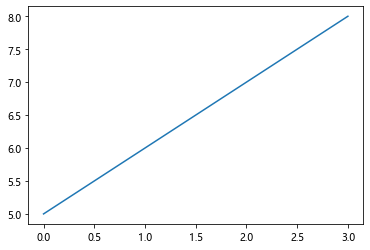

In [7]:
import matplotlib.pyplot as plt

x=list(range(4))
y1=[1,2,3,4]
y2=[5,6,7,8]
plt.plot(x,y1)
plt.savefig('1.jpg')
plt.clf()
plt.plot(x,y2)
plt.savefig('2.jpg')

In [3]:
import torch
import torch.nn.functional as F
a=torch.randn(1,2,3,2)
print(a)
a=F.normalize(a,p=2,dim=-1)
print(a)

tensor([[[[-2.0640, -1.3466],
          [-0.7758, -1.4181],
          [-0.8545,  1.9746]],

         [[ 0.9908,  0.3676],
          [ 0.2866,  1.1026],
          [-0.4639, -0.8430]]]])
tensor([[[[-0.8375, -0.5464],
          [-0.4799, -0.8773],
          [-0.3971,  0.9178]],

         [[ 0.9376,  0.3478],
          [ 0.2516,  0.9678],
          [-0.4821, -0.8761]]]])


In [8]:
attention=torch.randn(2,5,5)
print(attention)
topk = min(3, attention.size(-1))
knn_val, knn_ind = torch.topk(attention, topk, dim=-1)
#weighted_adjacency_matrix=(torch.ones_like(attention)).scatter_(-1,knn_ind,knn_val).to(self.device)
weighted_adjacency_matrix = (torch.zeros_like(attention)).scatter_(-1, knn_ind, knn_val)
print(weighted_adjacency_matrix)


tensor([[[ 1.2064e+00, -2.5634e+00, -5.0979e-01,  9.4343e-01,  9.7569e-01],
         [-1.6684e-02, -7.3909e-01,  7.5734e-01,  2.6611e-01, -5.3641e-01],
         [-8.6823e-01, -7.6349e-01, -9.4388e-01, -3.9807e-01, -1.5678e+00],
         [ 6.6732e-01, -7.7908e-01,  1.2201e+00,  2.5023e-01,  9.0611e-01],
         [-5.6887e-01,  1.1607e-01,  1.5883e-01,  7.6750e-02, -3.4678e-01]],

        [[-2.3591e-01,  2.2466e+00,  6.4003e-01, -2.5847e-01, -1.2341e+00],
         [-4.7454e-01, -2.0500e+00,  1.4886e+00, -1.7688e+00,  1.2286e+00],
         [ 5.2862e-02, -2.1396e-01, -4.6385e-01, -7.9506e-01,  2.0207e+00],
         [ 5.8456e-01,  1.8006e+00, -1.6922e-03,  4.1397e-01, -7.5465e-01],
         [-1.8945e+00,  2.3184e-01,  4.6243e-01, -1.3233e+00, -1.4607e-01]]])
tensor([[[ 1.2064,  0.0000,  0.0000,  0.9434,  0.9757],
         [-0.0167,  0.0000,  0.7573,  0.2661,  0.0000],
         [-0.8682, -0.7635,  0.0000, -0.3981,  0.0000],
         [ 0.6673,  0.0000,  1.2201,  0.0000,  0.9061],
         [ 0

In [4]:
import torch
device=torch.device('cpu')
x=torch.tensor([1,2,3])
x=x.to(device)
print(x)

tensor([1, 2, 3])


In [5]:
import torch
a=torch.tensor([[[4,2],[3,4]],[[5,6],[7,8]]])
print(a)
b=torch.max(a,dim=1,keepdim=True)[0]
print(b)

tensor([[[4, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
tensor([[[4, 4]],

        [[7, 8]]])


In [7]:
torch.tensor([1,1,1])*torch.max(torch.tensor([0,0,0]),5-torch.tensor([1,2,3]))

tensor([4, 3, 2])

In [12]:
from process import TimeDataset
import pandas as pd
data=pd.read_csv('./data/data/wadi/test.csv')
data=data.drop(columns='Timestamp')
data=TimeDataset(data,config)
for x,label in data:
    print(x.shape)



NameError: name 'config' is not defined

In [3]:
import d2l

In [7]:
import numpy as np

a=[[1,2],[3,4]]
a=np.array(a)
print(np.mean(a,axis=0)[1])

3.0


In [10]:
list=[[1,2],[3,4]]
print(len(list))

2


In [3]:
from sklearn.metrics import precision_score,recall_score
label=[1,1,0,0]
y=[0,1,0,0]
prec=precision_score(label,y)
rec=recall_score(label,y)
print(prec.item(),rec.item())

1.0 0.5


In [10]:
import torch
from torch import nn

Loss=nn.BCEWithLogitsLoss()
a=torch.tensor([1.0,1.0,2.0,0.0],dtype=float).to(torch.device('cuda'))
b=torch.tensor([1,1,1,0],dtype=float)
c=10*a
print(c)

tensor([10., 10., 20.,  0.], device='cuda:0', dtype=torch.float64)


In [11]:
import torch
a=torch.tensor([[[1,2]],[[3,4]]])
print(a.shape)
a=a.repeat(1,2,1)
print(a.shape)
b=torch.max(a,dim=1)[0]
print(b.shape)

torch.Size([2, 1, 2])
torch.Size([2, 2, 2])
torch.Size([2, 2])


In [4]:
import torch.nn.functional as F
import numpy as np
import torch
adj=torch.tensor([[[1,0],[1,1]],[[1,1],[0,1]]],dtype=float)
print(adj)
print(F.normalize(adj,p=1,dim=-1))

tensor([[[1., 0.],
         [1., 1.]],

        [[1., 1.],
         [0., 1.]]], dtype=torch.float64)
tensor([[[1.0000, 0.0000],
         [0.5000, 0.5000]],

        [[0.5000, 0.5000],
         [0.0000, 1.0000]]], dtype=torch.float64)


In [6]:
print(adj)
torch.sum(torch.pow(adj, 2), (1, 2)) / int(np.prod(adj.shape[1:]))

tensor([[[1., 0.],
         [1., 1.]],

        [[1., 1.],
         [0., 1.]]], dtype=torch.float64)


tensor([0.7500, 0.7500], dtype=torch.float64)

In [9]:
2*(0.6837*0.9923)/(0.6837+0.9923)

0.8095889140811455

In [8]:
2*0.9333*0.6141/(0.9333+0.6141)

0.7407774718883287

In [12]:
2*0.9238*0.6652/(0.9238+0.6652)

0.7734572183763373

In [13]:
2*0.8645*0.5836/(0.8645+0.5836)

0.6968057454595676

In [15]:
2*0.9908*0.9927/(0.9908+0.9927)

0.9917490899924376

In [16]:
2*0.9858*0.9956/(0.9858+0.9956)

0.9906757646108812

In [1]:
from torch.utils.tensorboard import SummaryWriter
import torch
import numpy as np

writer=SummaryWriter('./tr')

a=torch.rand(3,30)
label=['one','two','three']
writer.add_embedding(mat=a,metadata=label)


In [4]:
import numpy as np
print(2/np.sqrt(6))

0.8164965809277261


In [7]:
import torch
import torch.nn.functional as F

a=torch.tensor([[1,2,-1.0],[2,-1,3]],dtype=float)
print(a)
print(F.normalize(a,p=1,dim=1))

tensor([[ 1.,  2., -1.],
        [ 2., -1.,  3.]], dtype=torch.float64)
tensor([[ 0.2500,  0.5000, -0.2500],
        [ 0.3333, -0.1667,  0.5000]], dtype=torch.float64)


In [9]:
b=torch.ones_like(a)
print(torch.gt(a,b))

tensor(3)


In [ ]:
print(2*0.9635*0.6446/(0.9635+0.6446))

In [13]:
a=5493/44991
b=1006/17280
c=32047/39703
print(a,b,c)

0.1220910848836434 0.05821759259259259 0.8071682240636727
